# Explanatory Data Analysis

The dataset used in this notebook is **Labelled faces in the wild**. We edited the people.csv dataset provided by Kaggle, to include gender and race. By going through each and every photo within the dataset to correctly identify the gender and race.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

## Original Data

In [ ]:
data = pd.read_csv('/content/gdrive/My Drive/Masters/people.csv')
data.head()

,name,images
0,Abdel_Madi_Shabneh,1.0
1,Abdul_Rahman,1.0
2,Abel_Pacheco,4.0
3,Adriana_Lima,1.0
4,Afton_Smith,1.0


## Edited Data

In [ ]:
df = pd.read_csv('/content/gdrive/My Drive/Masters/people_gender_race.csv')
df.head()

,name,images,gender,race
0,Aaron_Eckhart,1,0,0
1,Aaron_Guiel,1,0,0
2,Aaron_Patterson,1,0,1
3,Aaron_Peirsol,4,0,0
4,Aaron_Pena,1,0,0


**Name** is the name of the labelled face. \\
**Images** is the number of images of that person. \\
**Gender** is Male (0) and Female (1). \\
**Race** is White/Caucasian (0), Black/Coloured (1), Middle Eastern (2), Asian (3) and Hispanic/Latino (4).

<ipython-input-8-3ba6f773fa01>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df['images'].value_counts()[:10], palette= "tab10")


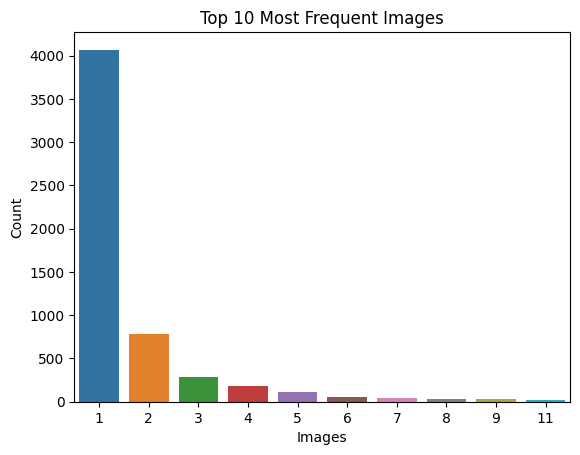

In [ ]:
sns.barplot(df['images'].value_counts()[:10], palette= "tab10")
plt.title('Top 10 Most Frequent Images')
plt.xlabel('Images')
plt.ylabel('Count')
plt.show()

## Gender

<ipython-input-6-d5887f9e27a2>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(df['gender'].value_counts().values),x= list(df['gender'].value_counts().index), palette= "tab10")
<ipython-input-6-d5887f9e27a2>:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax = ax.set_xticklabels(["Male","Female"])


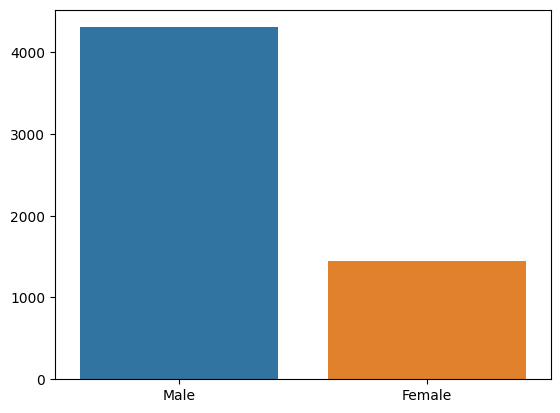

In [ ]:
sns.barplot(y=list(df['gender'].value_counts().values),x= list(df['gender'].value_counts().index), palette= "tab10")
ax = plt.subplot()
ax = ax.set_xticklabels(["Male","Female"])

## Race

<ipython-input-7-c8db5c2a57df>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(df['race'].value_counts().values),x= list(df['race'].value_counts().index), palette= "tab10")
<ipython-input-7-c8db5c2a57df>:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax = ax.set_xticklabels(["Caucasian", "Black/Colored", "MiddleEastern", "Asian", "Hispanic/Latino"])


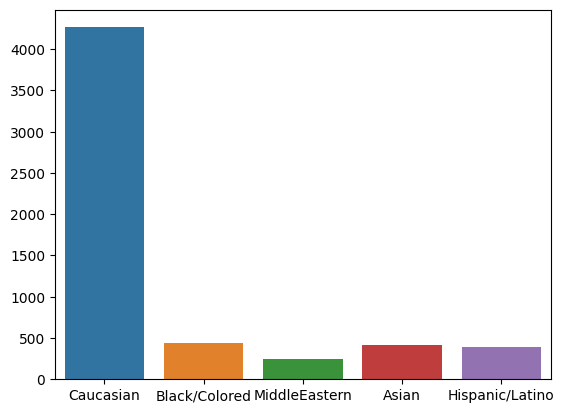

In [ ]:
sns.barplot(y=list(df['race'].value_counts().values),x= list(df['race'].value_counts().index), palette= "tab10")
ax = plt.subplot()
ax = ax.set_xticklabels(["Caucasian", "Black/Colored", "MiddleEastern", "Asian", "Hispanic/Latino"])

In [ ]:
# Libraries
import os
import glob
import random
import cv2
import base64
import imageio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
from copy import deepcopy
from torch.autograd import Variable
from tqdm import tqdm
from pprint import pprint
from PIL import Image
from sklearn.model_selection import train_test_split
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('Training on',DEVICE)

Training on cpu


In [ ]:
DATASET_PATH ="/content/gdrive/My Drive/Masters/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/content/gdrive/My Drive/Masters/lfw_attributes.csv"

In [ ]:
dataset = []
for path in glob.iglob(os.path.join(DATASET_PATH, "**", "*.jpg")):
    person = path.split("/")[-2]
    dataset.append({"name":person, "path": path})

dataset = pd.DataFrame(dataset)
#too much Bush
dataset = dataset.groupby("name").filter(lambda x: len(x) < 25 )
dataset.head(10)

,name,path
0,Rohman_al-Ghozi,/content/gdrive/My Drive/Masters/lfw-deepfunne...
1,Steve_Karsay,/content/gdrive/My Drive/Masters/lfw-deepfunne...
2,Shaun_Rusling,/content/gdrive/My Drive/Masters/lfw-deepfunne...
42,Melana_Scantlin,/content/gdrive/My Drive/Masters/lfw-deepfunne...
43,DAngelo_Jimenez,/content/gdrive/My Drive/Masters/lfw-deepfunne...
44,Newton_Carlton_Slawson,/content/gdrive/My Drive/Masters/lfw-deepfunne...
45,Ernest_Hollings,/content/gdrive/My Drive/Masters/lfw-deepfunne...
46,Beatrice_Dalle,/content/gdrive/My Drive/Masters/lfw-deepfunne...
47,Stacey_Dales-Schuman,/content/gdrive/My Drive/Masters/lfw-deepfunne...
48,Jenny_Romero,/content/gdrive/My Drive/Masters/lfw-deepfunne...


## Num. photos per person

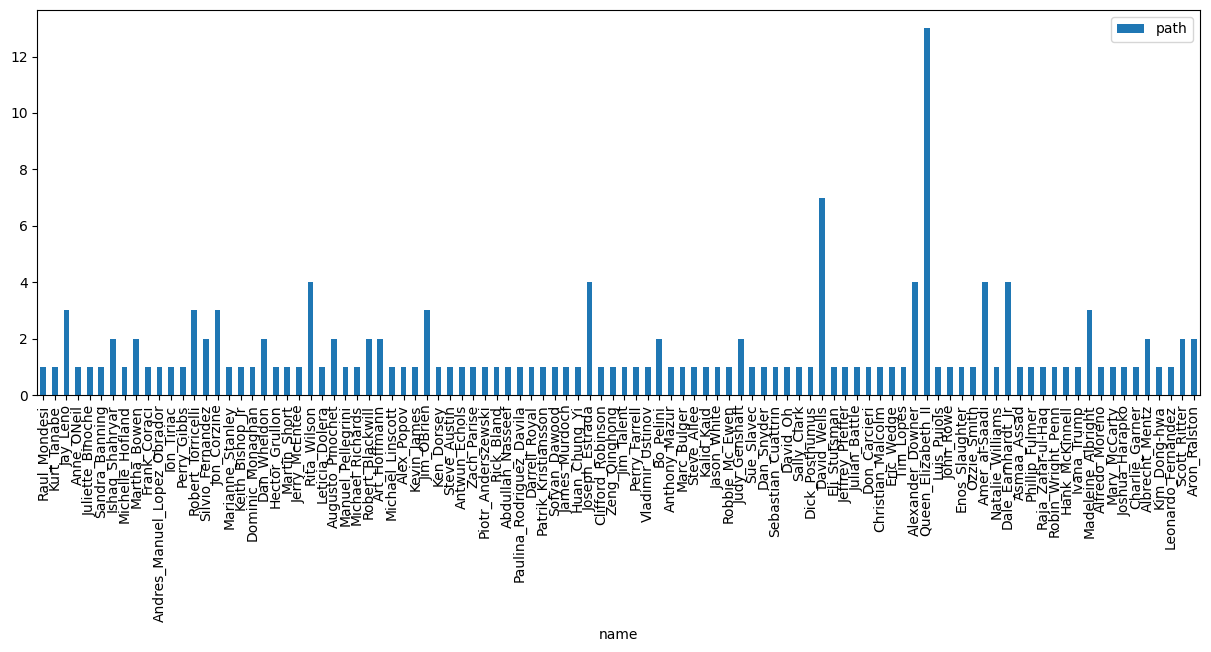

In [ ]:
random_sample = dataset.groupby("name").count().sample(n=100, random_state=1)

random_sample.plot(kind='bar', figsize=(15, 5))

plt.show()

## Example of the Labelled Faces in Wild

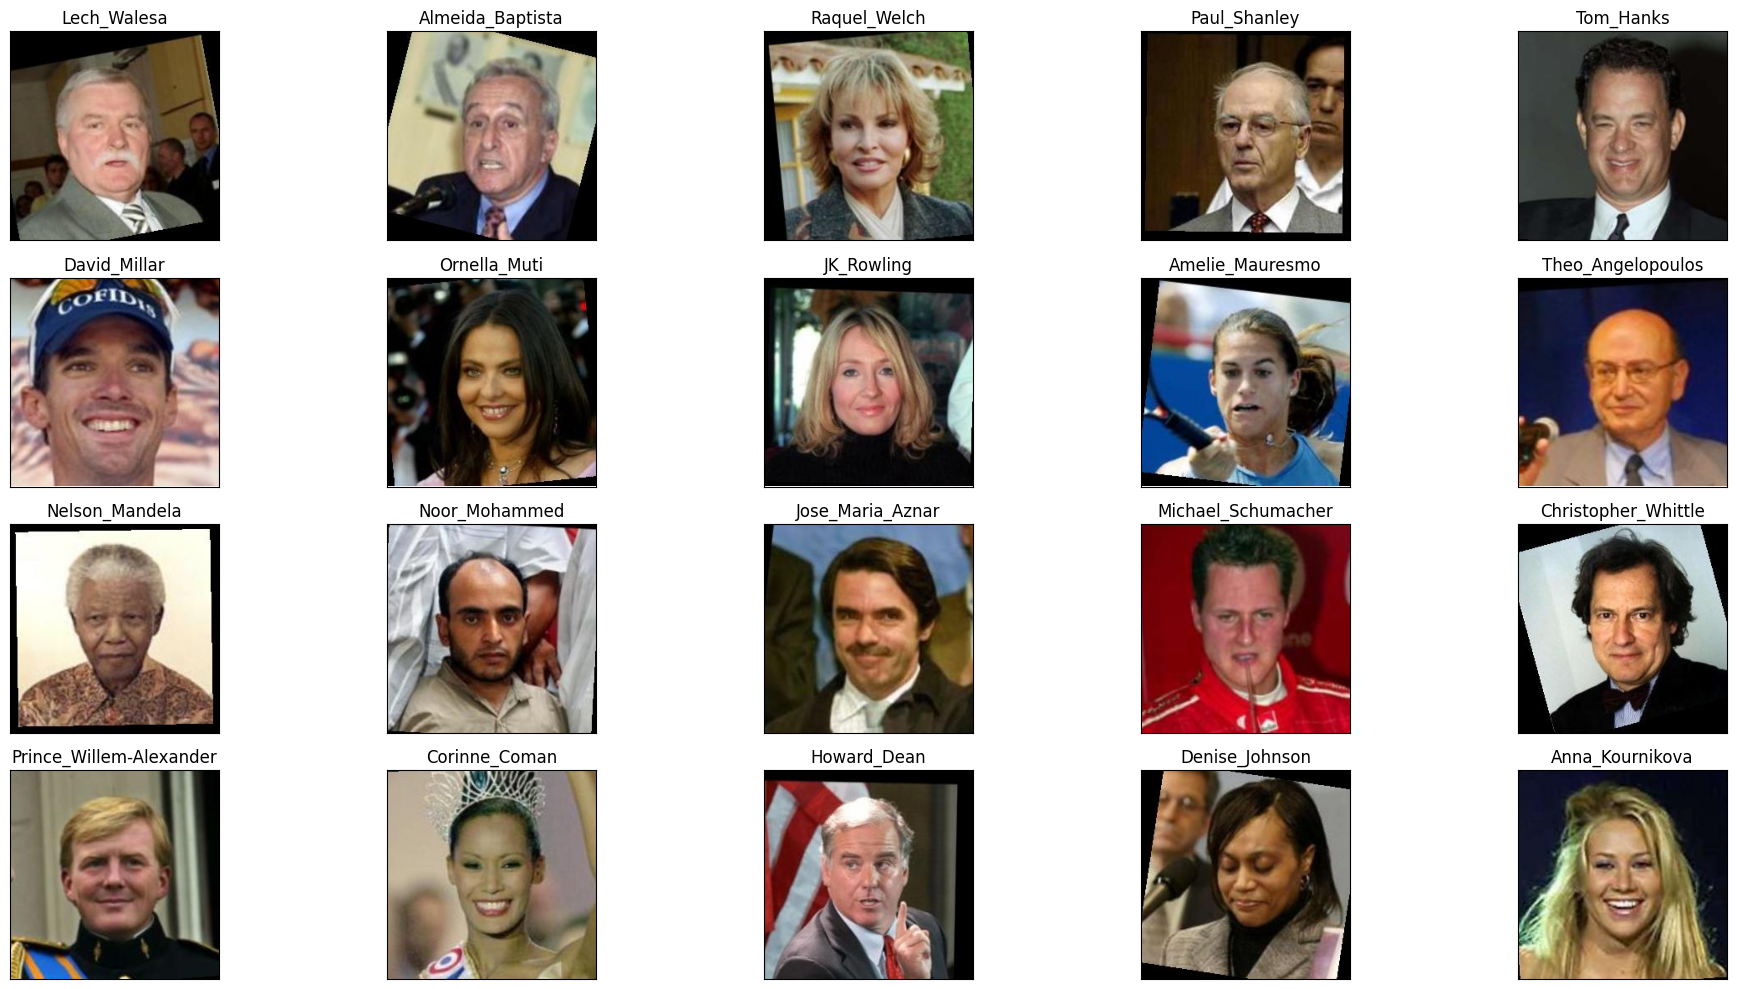

In [ ]:
plt.figure(figsize=(20,10))
for i in range(20):
    idx = random.randint(0, len(dataset))
    img = plt.imread(dataset.path.iloc[idx])
    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    plt.title(dataset.name.iloc[idx])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()